In [10]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

PKLs = []
PKL_titles = []
DIR = "./"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


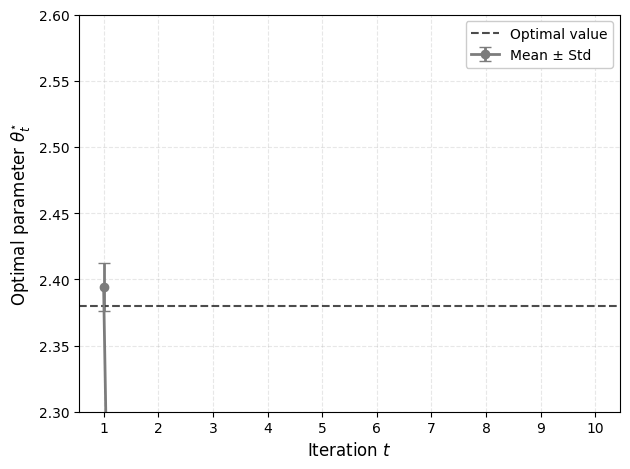

In [11]:
# Define color scheme
grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]

# Plot parameters evolution
idx = 0
max_iterations = 10
x_axis = range(1, max_iterations + 1)
all_parameters = PKLs[idx]['res'][3][:, :max_iterations]

# Main plot with error bars
plt.errorbar(x_axis, 
            np.mean(all_parameters, axis=0).squeeze(), 
            np.std(all_parameters, axis=0).squeeze(),
            color=grays[5],  # Mid-gray color
            linewidth=2,
            marker='o',
            markersize=6,
            capsize=4,
            label='Mean ± Std')

# Optional: Individual runs (commented out as per your 'if False' condition)
# for run in range(PKLs[idx]['res'][3].shape[0]):
#     plt.plot(x_axis, 
#              PKLs[idx]['res'][3][run, :max_iterations], 
#              alpha=0.2,
#              color=grays[2])

# Reference line at optimal value
plt.axhline(y=2.38, xmin=0, xmax=1, 
            linewidth=1.5, 
            color='k', 
            linestyle='--',
            alpha=0.7,
            label='Optimal value')

# Plot formatting
plt.ylabel(r'Optimal parameter $\theta_t^{\star}$', fontsize=12)
plt.xlabel(r'Iteration $t$', fontsize=12)
plt.ylim(2.3, 2.6)
plt.xticks(x_axis)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(framealpha=1, frameon=True)

plt.tight_layout()
plt.savefig(DIR + "RW_optimal_parameter.png", dpi=300, bbox_inches='tight')

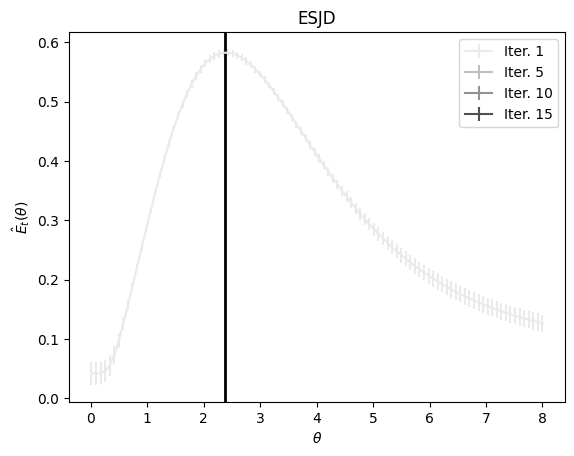

In [12]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]



idx = 0

criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
stds = jax.vmap(lambda x: x.std(axis=-1))(PKLs[idx]['res'][5].T).T

for j in range(PKLs[idx]['res'][5].shape[1]):
    plt.errorbar(GRID_ESJD, criteria_function[j], yerr=stds[j], label=f"Iter. {str(j+1)}" if j in [0, 4, 9, 14, 19] else None, color=grays[j//2], linestyle="solid" if  j in [0, 4, 9, 14, 19] else "--")
plt.axvline(x=2.38, ymin=0, ymax = 1, linewidth=2, color='k')
plt.legend()
plt.title("ESJD")
plt.ylabel(r"$\hat{E}_t(\theta)$")
plt.xlabel(r'$\theta$')
plt.savefig(DIR+f"{PKL_titles[idx]}criteria_function.png")

In [9]:
PKLs

[{'config': {'run': True,
   'num_parallel_chain': 32,
   'num_mcmc_steps': 4000,
   'parallel_repetitions': 10,
   'target_ess': 0.5,
   'low_memory': True,
   'b16': True,
   'dim': 5,
   'OUTPUT_PATH': './rw_g_to_g_fig1/',
   'prefix': 'config1',
   'problem': {'tau': 0.3323123922980408, 'latent_dim': 0},
   'optimization_method': 'make_optimize_within_a_fixed_grid',
   'params_optimization_method': {'grid': Array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 , 0.11,
           0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22,
           0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32, 0.33,
           0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43, 0.44,
           0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54, 0.55,
           0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65, 0.66,
           0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77,
           0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.8